# Question 1

In [25]:
from preprocess_assgn4 import preprocess

preprocess()

# Question 2

In [26]:
import pandas as pd

train_df = pd.read_csv('data/trainingSet.csv')
train_df = pd.read_csv('data/testSet.csv')

In [43]:
import numpy as np 



class Tree:
    def __init__(self, type):
        self.attribute = None
        self.type = type
        self.split = None
        self.l = None
        self.r = None

In [45]:

def create_leaf_node(data_frame, label):
    leaf_node = Tree(type='l')
    leaf_node.l = label
    leaf_node.r = label
    leaf_node.split = data_frame
    return leaf_node

def gini(data_frame, attribute, value):
    gini_impurity = 0
    subset_size = len(data_frame[data_frame[attribute] == value])
    unique_labels = np.unique(data_frame['decision'])

    for label in unique_labels:
        proportion = len(data_frame[(data_frame['decision'] == label) & (data_frame[attribute] == value)]) / subset_size
        gini_impurity += proportion ** 2

    return 1 - gini_impurity, subset_size



def calculate_gini_gain(data_frame, num_samples_per_class):
    gini_gain_dict = {}
    total_samples = len(data_frame)
    gini_S = 1 - sum((n / total_samples) ** 2 for n in num_samples_per_class)

    for attribute in data_frame.columns[:-1]:
        gini_gain = gini_S
        for value in np.unique(data_frame[attribute]):
            gini_SA, S_A = gini(data_frame, attribute, value)
            gini_gain -= (S_A / total_samples) * gini_SA
        gini_gain_dict[attribute] = gini_gain

    return gini_gain_dict


def split_data_frame(data_frame, attribute, is_forest):
    left_split = data_frame[data_frame[attribute] == 0]
    right_split = data_frame[data_frame[attribute] == 1]

    if is_forest:
        left_split = left_split.drop(attribute, axis=1)
        right_split = right_split.drop(attribute, axis=1)

    return left_split, right_split


def maketree(data_frame, current_depth, max_depth=8, min_samples_split=50, is_forest=False):
    if len(data_frame) == 0:
        return None

    unique_labels = np.unique(data_frame['decision'])
    if len(unique_labels) == 1:
        return create_leaf_node(data_frame, unique_labels[0])

    num_samples_per_class = [np.sum(data_frame['decision'] == label) for label in unique_labels]
    most_common_class = np.argmax(num_samples_per_class)
    if current_depth >= max_depth or len(data_frame) < min_samples_split:
        return create_leaf_node(data_frame, most_common_class)

    dict_ggain = calculate_gini_gain(data_frame, num_samples_per_class)

    if not dict_ggain:
        return create_leaf_node(data_frame, most_common_class)

    best_attribute = max(dict_ggain, key=dict_ggain.get)

    inode = Tree(type='i')
    inode.attribute = best_attribute
    inode.split = data_frame

    # Split the dataset and build subtrees
    left_split, right_split = split_data_frame(data_frame, best_attribute, is_forest)
    inode.l = maketree(left_split, current_depth + 1, max_depth, min_samples_split, is_forest)
    inode.r = maketree(right_split, current_depth + 1, max_depth, min_samples_split, is_forest)

    return inode

In [ ]:
tree = maketree(train_df, 0, 8, 50)
print_tree(tree)

In [56]:
def predict_dtree(node, sample):
    if node.type == 'l':
        return node.l
    if sample[node.attribute] == 0:
        return predict_dtree(node.l, sample)
    else:
        return predict_dtree(node.r, sample)
    
def calculate_accuracy_bagging(bagged_trees, dataset):
    correct_predictions = 0
    for index in range(len(dataset)):
        sample = dataset.iloc[index]
        p = [predict_dtree(tree, sample) for tree in bagged_trees]
        most_common_prediction = max(set(p), key=p.count)

        if most_common_prediction == sample['decision']:
            correct_predictions += 1

    return correct_predictions / len(dataset)


def calculate_accuracy_dtree(dtree, dataset):
    correct_predictions = 0
    for index in range(len(dataset)):
        sample = dataset.iloc[index]
        prediction = predict_dtree(dtree, sample)

        if prediction == sample['decision']:
            correct_predictions += 1

    return correct_predictions / len(dataset)


def train_bagging_ensemble(training_dataset, number_of_trees, is_forest, max_depth, min_samples):
    bagged_trees = []
    for _ in range(number_of_trees):
        pseudo_dataset = training_dataset.sample(frac=1, replace=True)
        tree = maketree(pseudo_dataset, 0, max_depth, min_samples, is_forest)
        bagged_trees.append(tree)
    
    return bagged_trees


In [57]:

def trees(training_data_filename='data/trainingSet.csv', test_data_filename='data/testSet.csv', model_idx=1):
    # Load training and testing data
    train_df = pd.read_csv(training_data_filename)
    test_df = pd.read_csv(test_data_filename)

    # Hyper-parameters for tree models
    max_depth = 8
    min_samples = 50

    if model_idx == 1:  # Decision Tree
        decision_tree = maketree(train_df, 0, max_depth, min_samples)
        train_accuracy = calculate_accuracy_dtree(decision_tree, train_df)
        test_accuracy = calculate_accuracy_dtree(decision_tree, test_df)
        print(f'Training Accuracy DT: {train_accuracy:.2f}')
        print(f'Testing Accuracy DT: {test_accuracy:.2f}')

    elif model_idx == 2:  # Bagging
        n_trees = 30
        bag_trees = train_bagging_ensemble(train_df, n_trees, False, max_depth, min_samples)
        train_accuracy = calculate_accuracy_bagging(bag_trees, train_df)
        test_accuracy = calculate_accuracy_bagging(bag_trees, test_df)
        print(f'Training Accuracy BT: {train_accuracy:.2f}')
        print(f'Testing Accuracy BT: {test_accuracy:.2f}')

    elif model_idx == 3:  # Random Forests
        n_trees = 30
        random_forests = train_bagging_ensemble(train_df, n_trees, True, max_depth, min_samples)
        train_accuracy = calculate_accuracy_bagging(random_forests, train_df)
        test_accuracy = calculate_accuracy_bagging(random_forests, test_df)
        print(f'Training Accuracy RF: {train_accuracy:.2f}')
        print(f'Testing Accuracy RF: {test_accuracy:.2f}')

In [61]:
trees('data/trainingSet.csv', 'data/testSet.csv', model_idx=1)


Training Accuracy DT: 0.78
Testing Accuracy DT: 0.70


In [62]:

trees('data/trainingSet.csv', 'data/testSet.csv', model_idx=2)

Training Accuracy BT: 0.79
Testing Accuracy BT: 0.75


In [63]:

trees('data/trainingSet.csv', 'data/testSet.csv', model_idx=3)

Training Accuracy RF: 0.80
Testing Accuracy RF: 0.75


# Question 3

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def shuffle_and_sample(train_df, shuffle_frac=1, sample_frac=0.5, shuffle_seed=18, sample_seed=32):
    shuffled = train_df.sample(frac=shuffle_frac, replace=False, random_state=shuffle_seed)
    sampled = shuffled.sample(frac=sample_frac, replace=False, random_state=sample_seed)
    return sampled

def k_fold_cross_validation(sampled_df, depth_values, k_folds=10):
    n_samples = len(sampled_df)
    n_fold = n_samples * k_folds / 100  

    results_mean = { 'DT': {'test': [], 'train': []},
                'BT': {'test': [], 'train': []},
                'RF': {'test': [], 'train': []} }

    results_stdev = { 'DT': {'test': [], 'train': []},
                'BT': {'test': [], 'train': []},
                'RF': {'test': [], 'train': []} }

    results = {'DT': [], 'BT': [], 'RF': []}

    for d in depth_values:
        accuracies = { 'DT': {'test': [], 'train': []},
                       'BT': {'test': [], 'train': []},
                       'RF': {'test': [], 'train': []} }

        for i in range(k_folds):
            start, end = int(i * n_fold), int((i + 1) * n_fold)
            test_df = sampled_df[start:end]
            train_df = sampled_df.drop(test_df.index)

            # Decision Tree
            tree = maketree(train_df, 0, d, 50, is_forest=False)
            accuracies['DT']['train'].append(calculate_accuracy_dtree(tree, train_df))
            accuracies['DT']['test'].append(calculate_accuracy_dtree(tree, test_df))

            # Bagging and Random Forest
            for model_type, label in [(False, 'BT'), (True, 'RF')]:
                ensemble = train_bagging_ensemble(train_df, 30, is_forest=model_type, max_depth=d, min_samples=50)
                accuracies[label]['train'].append(calculate_accuracy_bagging(ensemble, train_df))
                accuracies[label]['test'].append(calculate_accuracy_bagging(ensemble, test_df))

        for model in ['DT', 'BT', 'RF']:
            results_mean[model]['test'].append(np.mean(accuracies[model]['test']))
            results_mean[model]['train'].append(np.mean(accuracies[model]['train']))
            results_stdev[model]['test'].append(np.std(accuracies[model]['test']) / np.sqrt(k_folds))
            results_stdev[model]['train'].append(np.std(accuracies[model]['train']) / np.sqrt(k_folds))
            results[model].append(accuracies[model]['test'])

    return results_mean, results_stdev, results

# Usage
d = [3, 5, 7, 9]

train_df = pd.read_csv('data/trainingSet.csv')  # Replace with your dataset
sampled_df = shuffle_and_sample(train_df)
results_mean, results_stdev, results = k_fold_cross_validation(sampled_df, d)


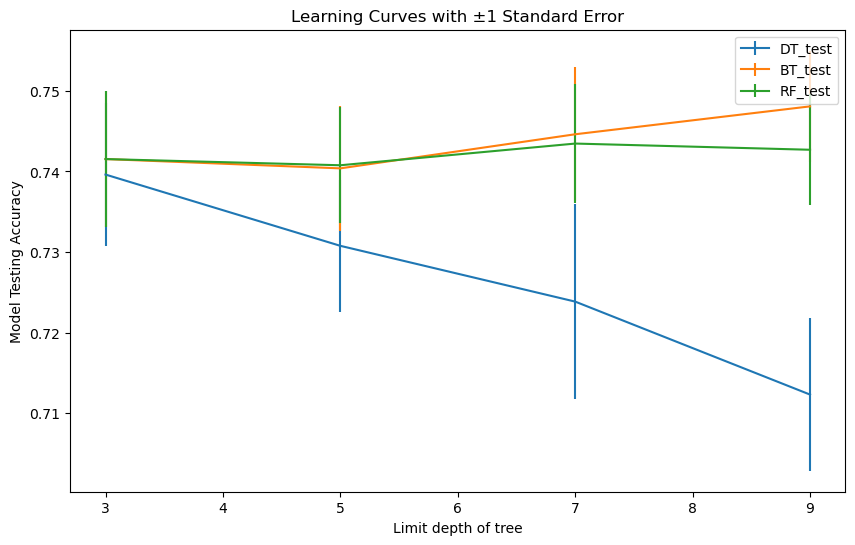

In [87]:

def plot_results(result_means, result_stdevs):
    plt.figure(figsize=(10, 6))
    for model in ['DT', 'BT', 'RF']:
        plt.errorbar(d, result_means[model]['test'], yerr=result_stdevs[model]['test'], label=f'{model}_test')

    plt.xlabel('Limit depth of tree')
    plt.ylabel('Model Testing Accuracy')
    plt.legend()
    plt.title('Learning Curves with ±1 Standard Error')
    plt.show()


plot_results(results_mean, results_stdev)

$H_0$: There is no significant difference in testing accuracy between Decision Trees and Random Forests for different depth of tree

$H_1$: There is a significant difference in testing accuracy between Decision Trees and Random Forests across different depth of tree


In [91]:
from scipy import stats

def perform_paired_t_test(dt_results, rf_results, alpha=0.05):
    for depth, bt_acc, rf_acc in zip(d, dt_results, rf_results):
        _, p_value = stats.ttest_rel(bt_acc, rf_acc)
        
        print(f'Depth: {depth}')
        if p_value < alpha:
            print(f"Reject H0 (p-value = {p_value:.3f} < alpha = 0.05)")
        else:
            print(f"Fail to reject H1 (p-value = {p_value:.3f} >= alpha = 0.05)")
        print()

# Usage
perform_paired_t_test(results['DT'], results['RF'])



Depth: 3
Fail to reject H1 (p-value = 0.177 >= alpha = 0.05)

Depth: 5
Fail to reject H1 (p-value = 0.155 >= alpha = 0.05)

Depth: 7
Reject H0 (p-value = 0.023 < alpha = 0.05)

Depth: 9
Reject H0 (p-value = 0.000 < alpha = 0.05)

